In [1]:
import tensorflow as tf
import tensorflow.keras as K
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
from skimage.transform import resize
import scipy.io
import matplotlib.pyplot as plt
import itertools
import time
import shutil
import os

In [6]:
from GAN import GAN
cell_dir='dataset_A/cell_level_label'

In [4]:
X_train = np.load(f'{cell_dir}/X_train.npy')
X_test = np.load(f'{cell_dir}/X_test.npy')
y_train = np.load(f'{cell_dir}/y_train.npy')
y_test = np.load(f'{cell_dir}/y_test.npy')

X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
for i in range(X_train.shape[0]):
    X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
for i in range(X_test.shape[0]):
    X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

X_train_resized = 2 * X_train_resized - 1
X_test_resized = 2 * X_test_resized - 1


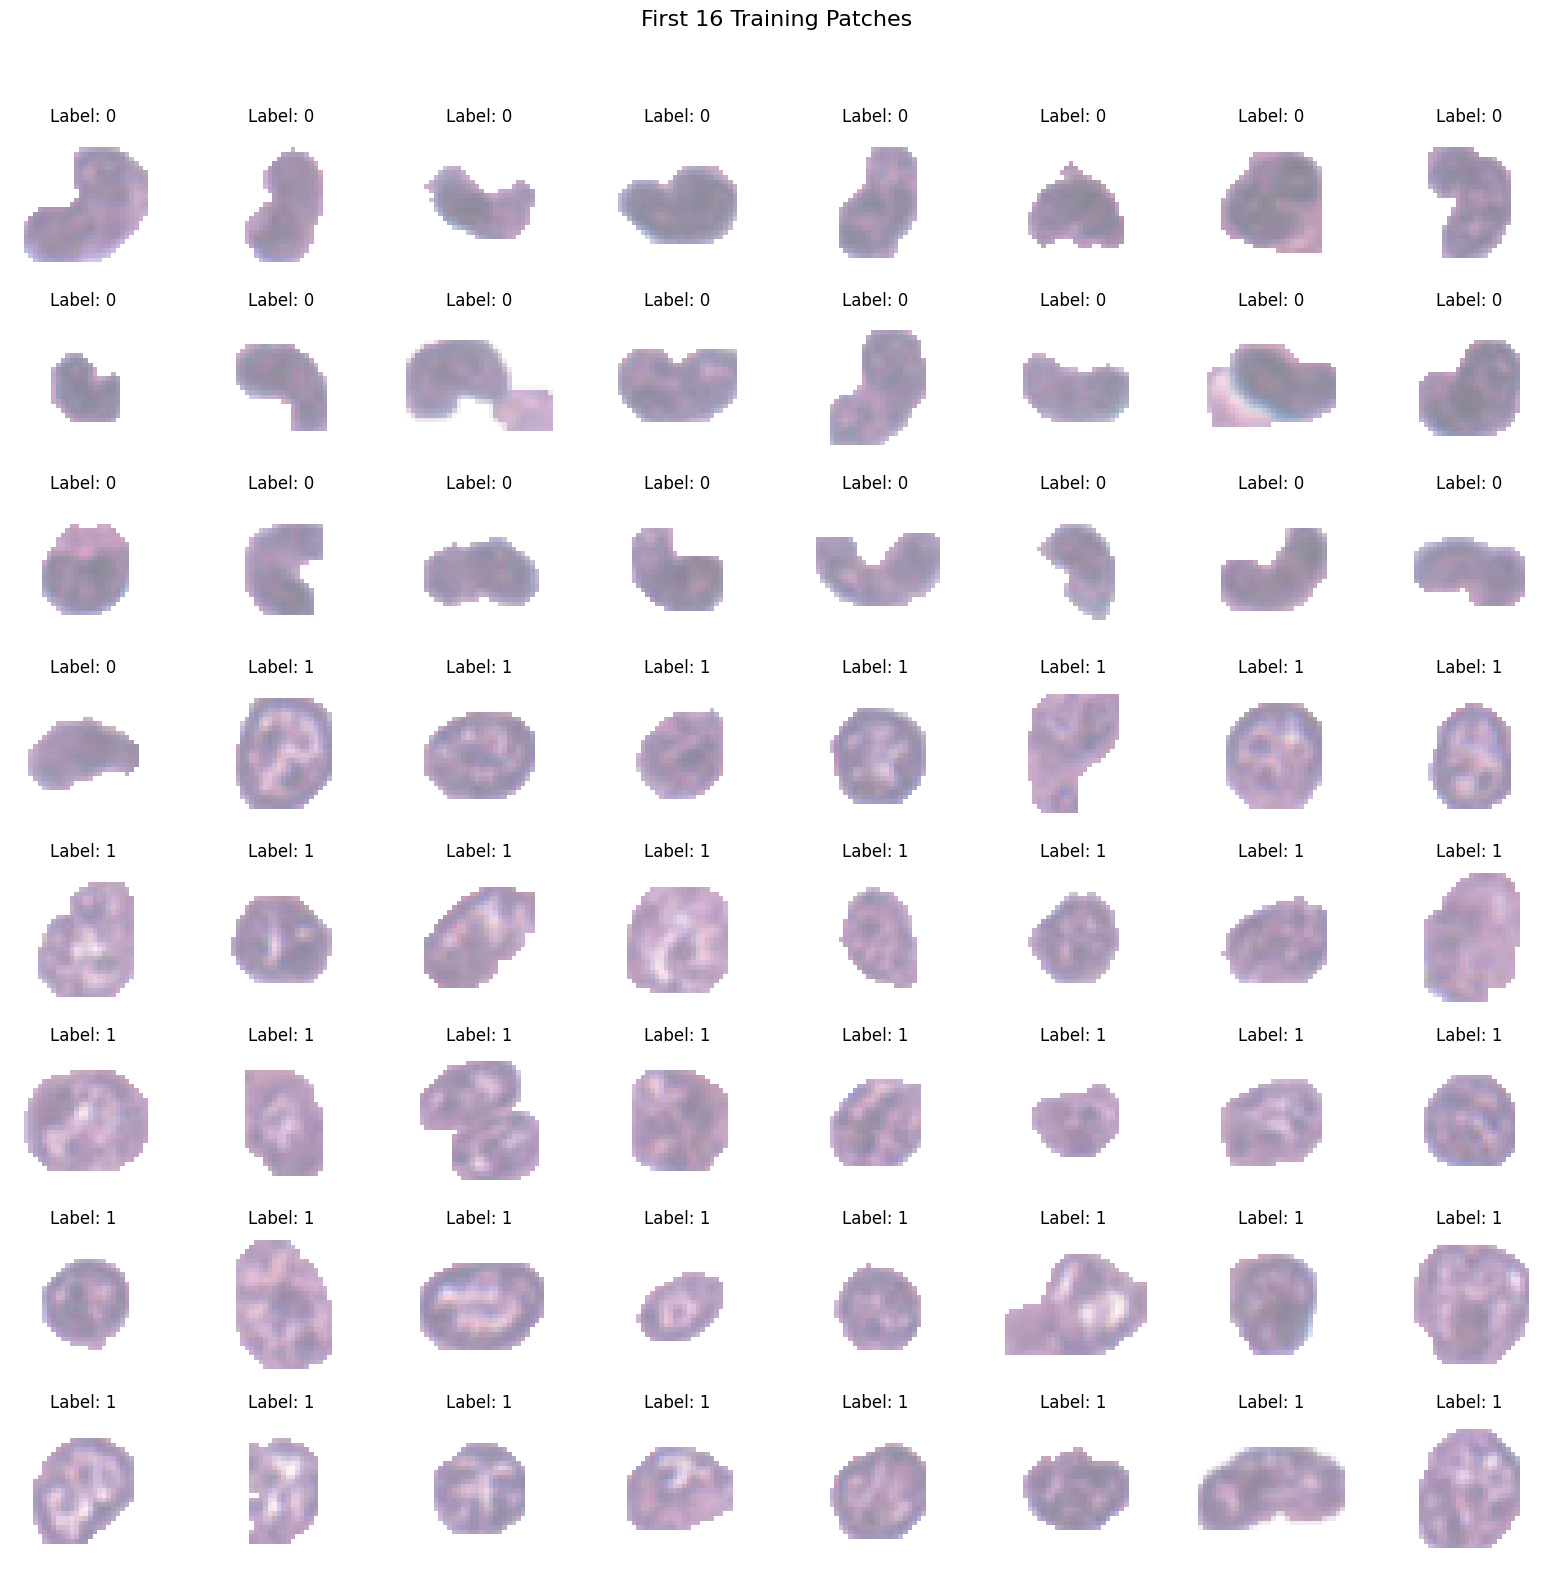

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

X_train = np.load(f'{cell_dir}/X_train.npy')   # shape (N, H, W, C)
y_train = np.load(f'{cell_dir}/y_train.npy')   # shape (N,) or (N,1)

# 2) (Re)resize to 32×32×3 and normalize back to [0,1] for display
X_train_resized = np.empty((X_train.shape[0], 32, 32, 3))
for i in range(X_train.shape[0]):
    X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

# Your model code normalized them to [-1,1], so invert that:
X_train_disp = (X_train_resized + 1) / 2.0

# 3) Plot the first 64 samples
n_plot = min(64, X_train_disp.shape[0])
plt.figure(figsize=(16, 16))
for idx in range(n_plot):
    ax = plt.subplot(8, 8, idx + 1)
    ax.imshow(X_train_disp[idx])
    lbl = y_train[idx][0] if y_train.ndim > 1 else y_train[idx]
    ax.set_title(f"Label: {lbl}")
    ax.axis('off')

plt.suptitle("First 64 Training Patches", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [16]:
Model = tf.keras.Model
gan = GAN()

start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=1000, batch_size=32, save_interval=5)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))

gan.save_model()

NameError: name 'Model' is not defined